**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist
from scipy.special import gamma

OUTPUT_DIR = os.getcwd()

RHO = 0.4
DOF = 3
GRID_STEP = 0.01

**Cell 2 — Grid on (0,1)^2**

In [2]:
u = np.arange(GRID_STEP, 1.00, GRID_STEP)
w = np.arange(GRID_STEP, 1.00, GRID_STEP)
U, W = np.meshgrid(u, w)

**Cell 3 — t-copula density function**

In [3]:
def t_copula_density(U, W, rho, dof):
    det_R = 1 - rho**2
    y1 = t_dist.ppf(U, dof)
    y2 = t_dist.ppf(W, dof)

    g = (1 / np.sqrt(det_R)) * gamma(dof/2 + 1) * gamma(dof/2) / gamma((dof + 1) / 2)**2
    Q = (y1**2 - 2 * rho * y1 * y2 + y2**2) / (det_R * dof)
    numer = (1 + y1**2 / dof) * (1 + y2**2 / dof)
    denom = 1 + Q

    return g * (numer ** ((dof + 1) / 2)) / (denom ** (dof / 2 + 1))

f = t_copula_density(U, W, RHO, DOF)

**Cell 4 — 3D surface plot**

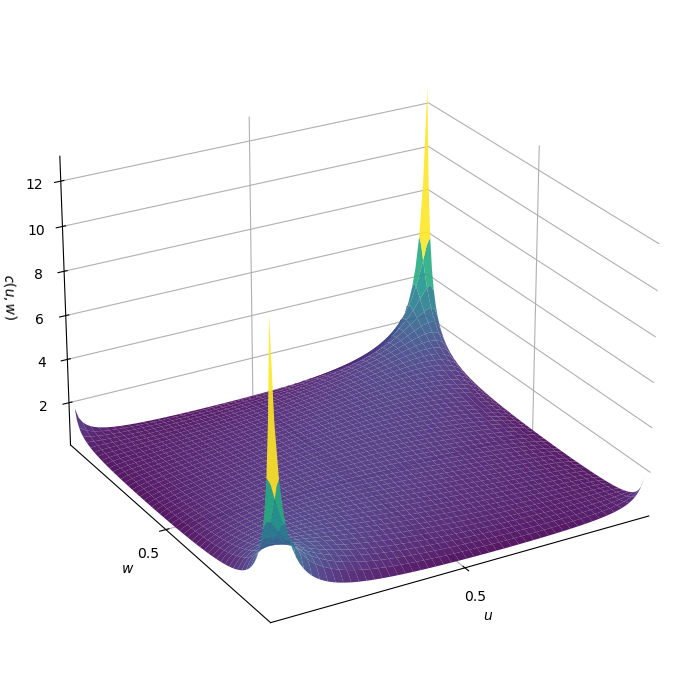

In [4]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(U, W, f, cmap="viridis", edgecolor="none", alpha=0.9)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("white")
ax.yaxis.pane.set_edgecolor("white")
ax.zaxis.pane.set_edgecolor("white")

ax.set_xlabel("$u$")
ax.set_ylabel("$w$")
ax.set_zlabel("$c(u,w)$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([0.5])
ax.set_yticks([0.5])
ax.view_init(elev=25, azim=240)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "t_copula_density.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Directory for temporary frames
frames_dir = os.path.join(OUTPUT_DIR, "frames")
os.makedirs(frames_dir, exist_ok=True)

fig = plt.figure(figsize=(8, 6))
fig.patch.set_alpha(0)

ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor((1, 1, 1, 0))

ax.plot_surface(U, W, f, cmap="viridis", edgecolor="none", alpha=0.9)

# Transparent panes
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_facecolor((1, 1, 1, 0))
    axis.pane.set_edgecolor((1, 1, 1, 0))

ax.set_xlabel("$u$")
ax.set_ylabel("$v$")
ax.set_zlabel("$c(u,v)$")
# ax.set_title(f"t-Student Copula Density (rho = {RHO}, dof = {DOF})", fontsize=13)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Save transparent PNG frames
n_frames = 72

for i, angle in enumerate(np.linspace(0, 360, n_frames, endpoint=False)):
    ax.view_init(elev=25, azim=angle)

    frame_path = os.path.join(frames_dir, f"frame_{i:03d}.png")
    fig.savefig(
        frame_path,
        dpi=120,
        transparent=True,
        bbox_inches="tight",
        pad_inches=0,
    )

plt.close(fig)

# Assemble GIF
frames = [Image.open(os.path.join(frames_dir, f"frame_{i:03d}.png"))
          for i in range(n_frames)]

# Convert to palette mode while preserving transparency
palette_frames = []
for im in frames:
    im = im.convert("RGBA")
    pal = im.convert("P", palette=Image.ADAPTIVE)
    alpha = im.getchannel("A")
    mask = Image.eval(alpha, lambda a: 255 if a <= 128 else 0)
    pal.paste(255, mask)              # palette index 255 becomes transparent
    pal.info["transparency"] = 255
    palette_frames.append(pal)

gif_path = os.path.join(OUTPUT_DIR, "transparent_tstudent_copula_density_rotation.gif")

palette_frames[0].save(
    gif_path,
    save_all=True,
    append_images=palette_frames[1:],
    duration=1000 // 15,
    loop=0,
    transparency=255,
    disposal=2,
)

for f in os.listdir(frames_dir):
    os.remove(os.path.join(frames_dir, f))
os.rmdir(frames_dir)